# RL-Based Path Planning (Tabular)

This notebook demonstrates path planning using tabular reinforcement learning agents from the `rlforge` library. The agents learn a navigation policy by interacting with a grid-world environment, then extract a path via greedy rollout.

In [8]:
import numpy as np
from pathplan.core import GridMap
from pathplan.rl import (
    QLearningPlanner,
    SarsaPlanner
)
from pathplan.utils import Visualizer

In [9]:
# Recreating the scenario map parameters
maze_data = np.zeros((20, 20))

# Vertical wall with an open gap
maze_data[5:15, 10] = 1.0
maze_data[10, 10] = 0.0  

# Horizontal wall with an open gap
maze_data[12, 3:17] = 1.0
maze_data[12, 8] = 0.0   

# Static block obstacles
maze_data[3:5, 3:5] = 1.0
maze_data[7:9, 15:18] = 1.0
maze_data[16:18, 5:7] = 1.0

# Define start and goal configurations (row, col indices)
start_node = (0, 0)
goal_node = (19, 19)

# Instantiate the normalized GridMap wrapper
grid_map = GridMap(maze_data)
print(f"GridMap successfully initialized with shape: {grid_map.shape}")

GridMap successfully initialized with shape: (20, 20)



Running Q-Learning...


SUCCESS: Valid trajectory discovered for Q-Learning!
Total steps in path: 65


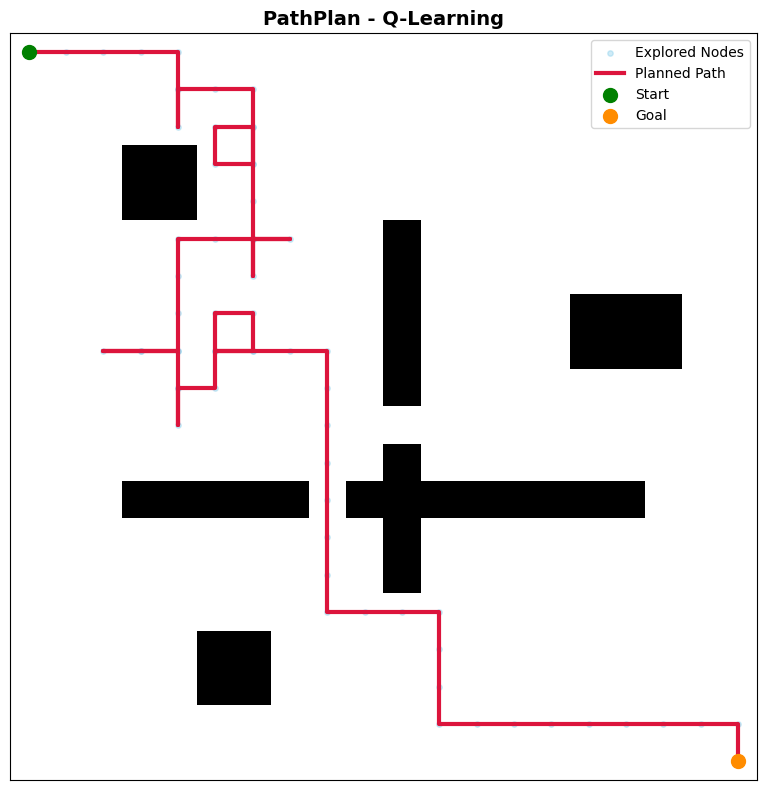


Running SARSA...


SUCCESS: Valid trajectory discovered for SARSA!
Total steps in path: 51


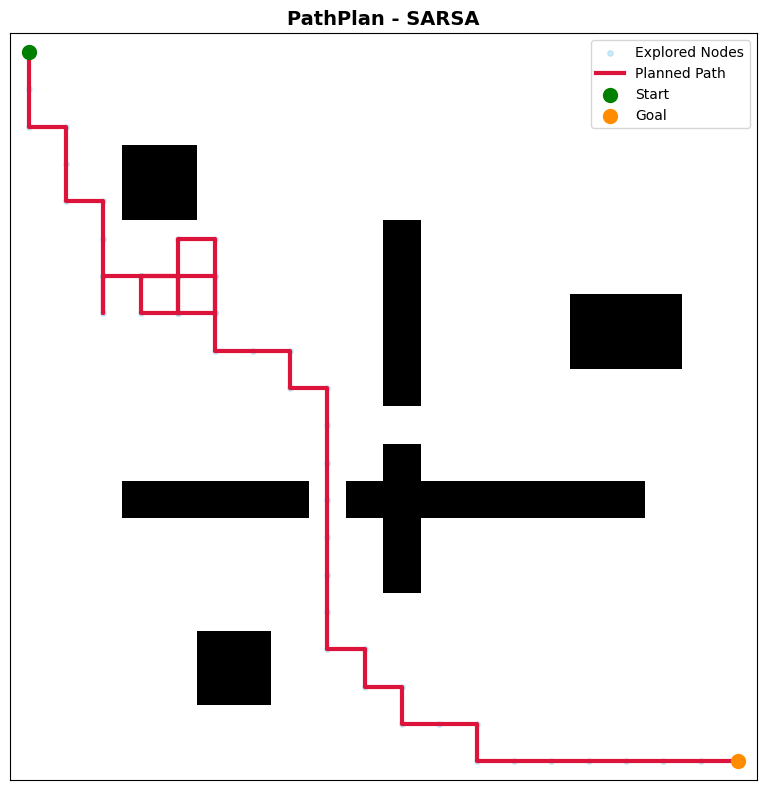

In [ ]:
# Define the tabular RL planners to demonstrate
# Each learns a policy by interacting with the grid-world for N episodes.
planners = [
    ("Q-Learning", QLearningPlanner(grid_map, num_episodes=100, max_steps=200)),
    ("SARSA", SarsaPlanner(grid_map, num_episodes=100, max_steps=200)),
]

viz = Visualizer(grid_map)

for name, planner in planners:
    print(f"\nRunning {name}...")
    path, explored = planner.plan(start_node, goal_node)
    
    if path:
        print(f"SUCCESS: Valid trajectory discovered for {name}!")
        print(f"Total steps in path: {len(path)}")
        viz.plot_path(
            path=path, 
            explored=explored, 
            title=f"PathPlan - {name}"
        )
    else:
        print(f"FAILURE: {name} could not find a valid path.")